In [13]:
# Install the sentence-transformers library
!pip install sentence-transformers

In [14]:
# Import all the tools we need
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

In [15]:
# 10 sentences across 3 topics (Cricket, Cooking, Cybersecurity)
sentences = [
    # Cricket (4 sentences)
    "The batsman hit a magnificent six over the boundary.",
    "India won the test match by an innings and 50 runs.",
    "The spinner bowled a perfect googly to dismiss the opener.",
    "The fielder took a stunning catch near the boundary rope.",

    # Cooking (3 sentences)
    "Always preheat the oven before baking a cake.",
    "Add a pinch of salt to enhance the flavor of the dish.",
    "Simmer the sauce on low heat for twenty minutes.",

    # Cybersecurity (3 sentences)
    "A firewall helps protect your network from unauthorized access.",
    "Phishing emails trick users into revealing their passwords.",
    "Always use two-factor authentication to secure your accounts."
]

# Short labels for the heatmap axes
labels = [
    "Cricket 1", "Cricket 2", "Cricket 3", "Cricket 4",
    "Cooking 1", "Cooking 2", "Cooking 3",
    "Cyber 1",   "Cyber 2",   "Cyber 3"
]

print(f"Total sentences: {len(sentences)}")

Total sentences: 10


In [16]:
# Load the pre-trained model
# This model converts text into 384-dimensional number vectors
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings — each sentence becomes a list of 384 numbers
embeddings = model.encode(sentences)

print(f"Embedding shape: {embeddings.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape: (10, 384)


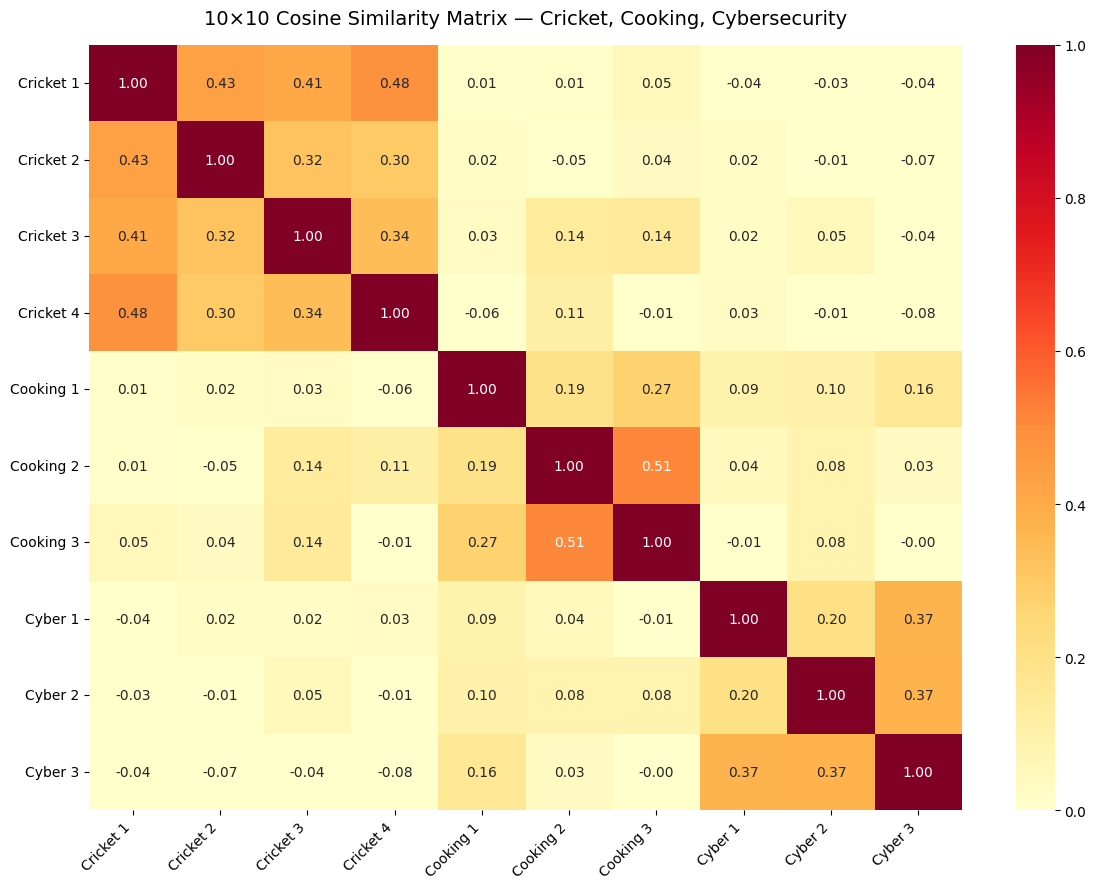

Heatmap displayed successfully!


In [17]:
# Compute cosine similarity between every pair of sentences
# Result is a 10x10 matrix where 1.0 = identical, 0.0 = unrelated
similarity_matrix = cosine_similarity(embeddings)

# Plot the heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    similarity_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,           # Show numbers inside each cell
    fmt=".2f",            # Round to 2 decimal places
    cmap="YlOrRd",        # Color: yellow (low) → red (high)
    vmin=0, vmax=1        # Scale from 0 to 1
)
plt.title("10×10 Cosine Similarity Matrix — Cricket, Cooking, Cybersecurity",
          fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150)  # Saves a copy
plt.show()
print("Heatmap displayed successfully!")

In [18]:
# The query sentence we want to find matches for
query = "The bowler took three wickets in one over"

# Convert query to embedding using the same model
query_embedding = model.encode([query])

# Compute similarity between query and all 10 sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get indices sorted from most similar to least similar
sorted_indices = np.argsort(query_similarities)[::-1]

# Print results
print(f"Query: '{query}'\n")
print("Top 2 Most Similar Sentences:")
print("-" * 50)
for rank, idx in enumerate(sorted_indices[:2], start=1):
    print(f"Rank {rank}:")
    print(f"  Sentence : {sentences[idx]}")
    print(f"  Similarity: {query_similarities[idx]:.4f}")
    print()

Query: 'The bowler took three wickets in one over'

Top 2 Most Similar Sentences:
--------------------------------------------------
Rank 1:
  Sentence : The batsman hit a magnificent six over the boundary.
  Similarity: 0.5549

Rank 2:
  Sentence : India won the test match by an innings and 50 runs.
  Similarity: 0.5491

